# Embedding Demos: Corpus Dependence (Word2Vec) vs Context Dependence (BERT)

This notebook demonstrates two ideas:
1. **Nearest neighbors change** depending on the **training corpus** (Word2Vec).
2. **Contextual embeddings** (BERT) produce **different vectors for the same word** depending on sentence context.

It also exports embeddings to **TensorFlow Embedding Projector**-compatible TSV files.

## Requirements
- `gensim`
- `numpy`, `pandas`
- `scikit-learn`
- `matplotlib`
- `transformers`, `torch`

If you’re missing packages, run the optional install cell below.


In [1]:
# Optional: install dependencies (uncomment if needed)
!pip install -U gensim numpy pandas scikit-learn matplotlib transformers torch


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 13.5 MB/s  0:00:014.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 13.4 MB/s  0:00:00 13.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.5 MB/s  0:00:002.3 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 9.8 MB/s  0:00:0011.4 MB/s eta 0:00:01
  Attempting uninstall: pandas━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 5/9 [contourpy]
    Found existing installation: pandas 2.3.338;5;237m╺━━━━━━━━━━━━━━━━━ 5/9 [contourpy]
    Uninstalling pandas-2.3.3:━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 5/9 [contourpy]
      Successfully uninstalled pandas-2.3.3╺━━━━━━━━━━━━━━━━━ 5/9 [contourpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [gensim];5;237m━━━━ 8/9 [gensim]
ERROR: pip's dependency resolver does not currently take into account all the packages that are i

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


## Part A — Word2Vec: Nearest Neighbors Change with the Corpus

We will train **two Word2Vec models** on two tiny corpora:
- A **finance** corpus (bank → loan, credit, …)
- A **river/nature** corpus (bank → river, shore, …)

With real corpora (news vs novels, etc.), the effect is even more striking.

In [3]:
from gensim.models import Word2Vec

def simple_tokenize(text: str):
    # lowercase, keep simple words
    return re.findall(r"[a-z']+", text.lower())

finance_sentences = [
    "The bank approved the loan and increased credit limits.",
    "Investment banking and capital markets affect interest rates.",
    "The borrower refinanced the mortgage at a lower rate.",
    "The lender evaluated risk and adjusted the portfolio.",
    "The bank issued a new credit card with rewards.",
    "Stocks, bonds, and liquidity matter to the bank.",
    "The loan officer discussed collateral and repayment terms.",
    "The central bank changed policy and impacted inflation.",
]

river_sentences = [
    "The fisherman sat by the bank of the river.",
    "We walked along the shore near the river bank.",
    "The flood covered the bank and washed debris downstream.",
    "The canoe drifted toward the bank in the current.",
    "Trees grew on the bank beside the water.",
    "The river curved around the bank and formed a bend.",
    "Birds nested near the bank and reeds.",
    "The hikers rested on the grassy bank.",
]

finance_corpus = [simple_tokenize(s) for s in finance_sentences]
river_corpus   = [simple_tokenize(s) for s in river_sentences]

w2v_fin = Word2Vec(sentences=finance_corpus, vector_size=100, window=5, min_count=1, sg=1, epochs=200, seed=42)
w2v_riv = Word2Vec(sentences=river_corpus,   vector_size=100, window=5, min_count=1, sg=1, epochs=200, seed=42)

target = "bank"

def show_neighbors(model, word, topn=10):
    return pd.DataFrame(model.wv.most_similar(word, topn=topn), columns=["neighbor", "similarity"]) 

neighbors_fin = show_neighbors(w2v_fin, target)
neighbors_riv = show_neighbors(w2v_riv, target)

neighbors_fin, neighbors_riv

(   neighbor  similarity
 0       the    0.979571
 1       and    0.974814
 2         a    0.964981
 3   markets    0.949636
 4  interest    0.948928
 5   capital    0.947824
 6   rewards    0.947577
 7   banking    0.947533
 8    affect    0.946125
 9       new    0.943676,
   neighbor  similarity
 0      the    0.992088
 1      and    0.986444
 2    river    0.977641
 3   formed    0.970495
 4    flood    0.969933
 5   washed    0.967903
 6        a    0.967903
 7       we    0.964955
 8  covered    0.962626
 9     near    0.961503)

### Discussion
- Both models contain the token **bank**, but its **nearest neighbors differ** because the **training contexts differ**.
- This is a great way to illustrate that **embeddings are corpus-dependent**.


## Part B — Visualize the Shift (2D PCA)
We’ll plot a small set of words (target + top neighbors) for each model in 2D using PCA.

Note: PCA is a projection; it’s useful for intuition, not proof.

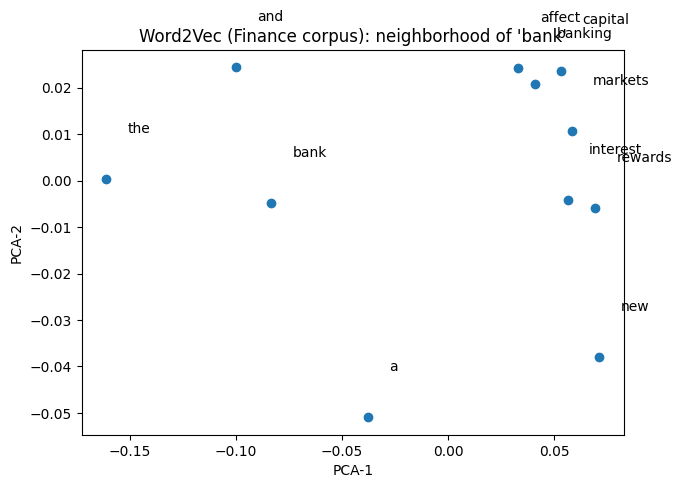

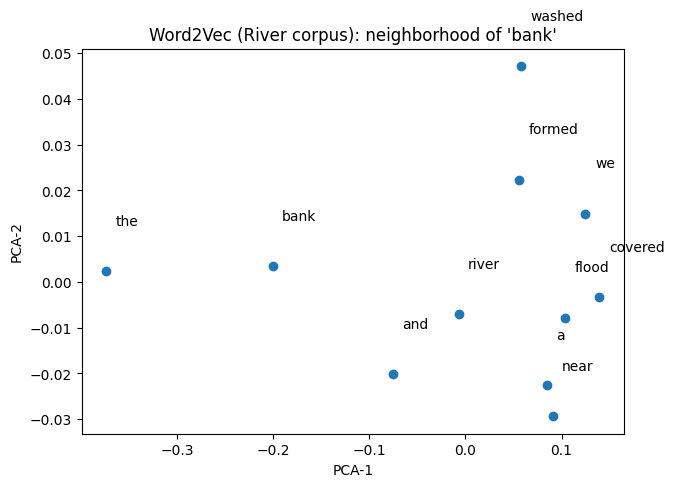

In [4]:
def pca_plot(model, center_word, title, topn=10):
    words = [center_word] + [w for w, _ in model.wv.most_similar(center_word, topn=topn)]
    X = np.vstack([model.wv[w] for w in words])
    X2 = PCA(n_components=2, random_state=0).fit_transform(X)

    plt.figure(figsize=(7,5))
    plt.scatter(X2[:,0], X2[:,1])
    for i, w in enumerate(words):
        plt.text(X2[i,0] + 0.01, X2[i,1] + 0.01, w)
    plt.title(title)
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.show()

pca_plot(w2v_fin, target, "Word2Vec (Finance corpus): neighborhood of 'bank'")
pca_plot(w2v_riv, target, "Word2Vec (River corpus): neighborhood of 'bank'")


## Part C — BERT: Contextual Embeddings
Word2Vec gives **one vector per word type**.

BERT gives a **different vector per word occurrence**, depending on its context.

We’ll compute embeddings for the token **bank** in two sentences:
- “The bank approved the loan.”
- “The fisherman sat by the bank.”

Then we’ll compare the vectors and measure cosine similarity.

Note: BERT uses **subword tokens**, so we will locate the subwords that correspond to the word and **average** them.


In [9]:
import re
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, BertForPreTraining

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = BertForPreTraining.from_pretrained(model_name)
bert.eval()

sent1 = "The bank approved the loan."
sent2 = "The fisherman sat by the bank."
word  = "bank"

def bert_word_embedding(sentence: str, word: str):
    # tokenize with offsets so we can map back to the original string
    enc = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
    offsets = enc.pop("offset_mapping")[0].tolist()
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    # Find the last occurrence of the word in the original string
    matches = list(re.finditer(r"\b" + re.escape(word.lower()) + r"\b", sentence.lower()))
    if not matches:
        raise ValueError(f"Word '{word}' not found in: {sentence}")
    span = matches[-1].span()  # (start_char, end_char)

    # Determine which tokens overlap that span
    token_idxs = []
    for i, (s, e) in enumerate(offsets):
        if s == e:  # special tokens like [CLS]/[SEP]
            continue
        if not (e <= span[0] or s >= span[1]):  # overlap check
            token_idxs.append(i)
    if not token_idxs:
        raise RuntimeError("Could not map word span to tokens.")

    with torch.no_grad():
        # IMPORTANT: call the base encoder to get last_hidden_state
        out = bert.bert(input_ids=input_ids, attention_mask=attention_mask)
        H = out.last_hidden_state[0]  # [seq_len, hidden]

    # average subword vectors
    v = H[token_idxs].mean(dim=0).cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    mapped_tokens = [tokens[i] for i in token_idxs]
    return v, tokens, mapped_tokens, span

v1, tokens1, mapped1, span1 = bert_word_embedding(sent1, word)
v2, tokens2, mapped2, span2 = bert_word_embedding(sent2, word)

sim = float(cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0, 0])

print("Sentence 1:", sent1)
print("Tokens:", tokens1)
print("Mapped subwords for 'bank':", mapped1, " span:", span1)
print()
print("Sentence 2:", sent2)
print("Tokens:", tokens2)
print("Mapped subwords for 'bank':", mapped2, " span:", span2)
print()
print("Cosine similarity between contextual embeddings of 'bank':", round(sim, 4))



Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

Sentence 1: The bank approved the loan.
Tokens: ['[CLS]', 'the', 'bank', 'approved', 'the', 'loan', '.', '[SEP]']
Mapped subwords for 'bank': ['bank']  span: (4, 8)

Sentence 2: The fisherman sat by the bank.
Tokens: ['[CLS]', 'the', 'fisherman', 'sat', 'by', 'the', 'bank', '.', '[SEP]']
Mapped subwords for 'bank': ['bank']  span: (25, 29)

Cosine similarity between contextual embeddings of 'bank': 0.5148


### What you should see
- Word2Vec: one embedding for **bank** (finance vs river only changes if you retrain on a different corpus).
- BERT: two different embeddings for **bank** in two different contexts, even with the same pretrained model.

This is the cleanest way to teach **corpus-dependence** vs **context-dependence**.


## Part D — Compare Word2Vec and BERT Embeddings Visually (2D PCA)
We will build a combined plot:
- Word2Vec neighbors of *bank* (from one corpus)
- The two BERT contextual vectors of *bank* (two sentences)

They are different embedding spaces (trained differently), so treat this as an intuition tool, not a strict comparison.


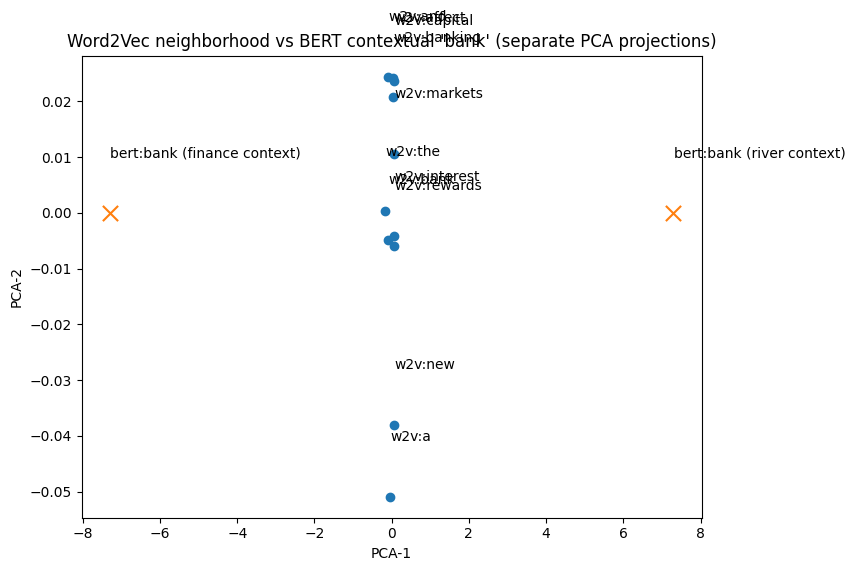

In [6]:
# Build a small set of Word2Vec vectors + the two BERT vectors
words = [target] + [w for w, _ in w2v_fin.wv.most_similar(target, topn=10)]
X_w2v = np.vstack([w2v_fin.wv[w] for w in words])

# To concatenate with BERT vectors, we need to match dimensionalities.
# Word2Vec is 100-d here; BERT is 768-d. We'll PCA them separately for visualization.

X2_w2v = PCA(n_components=2, random_state=0).fit_transform(X_w2v)
X2_bert = PCA(n_components=2, random_state=0).fit_transform(np.vstack([v1, v2]))

plt.figure(figsize=(8,6))
plt.scatter(X2_w2v[:,0], X2_w2v[:,1])
for i, w in enumerate(words):
    plt.text(X2_w2v[i,0] + 0.01, X2_w2v[i,1] + 0.01, f"w2v:{w}")

plt.scatter(X2_bert[:,0], X2_bert[:,1], marker='x', s=120)
plt.text(X2_bert[0,0] + 0.01, X2_bert[0,1] + 0.01, "bert:bank (finance context)")
plt.text(X2_bert[1,0] + 0.01, X2_bert[1,1] + 0.01, "bert:bank (river context)")

plt.title("Word2Vec neighborhood vs BERT contextual 'bank' (separate PCA projections)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.show()


## Part E — Export to TensorFlow Embedding Projector (TSV)
TensorFlow’s Embedding Projector expects:
- `vectors.tsv`: tab-separated vectors (one row per item)
- `metadata.tsv`: labels (one row per item)

We’ll export two sets:
1. Word2Vec neighborhood of `bank` (finance corpus)
2. BERT contextual vectors for `bank` in our two sentences

You can upload these at `projector.tensorflow.org`.


In [7]:
from pathlib import Path

out_dir = Path("embedding_exports")
out_dir.mkdir(exist_ok=True)

def export_tsv(vectors: np.ndarray, labels: list[str], vec_path: Path, meta_path: Path):
    assert vectors.shape[0] == len(labels)
    # vectors
    with vec_path.open("w", encoding="utf-8") as f:
        for row in vectors:
            f.write("\t".join(map(lambda x: f"{x:.6f}", row.tolist())) + "\n")
    # metadata
    with meta_path.open("w", encoding="utf-8") as f:
        for lab in labels:
            f.write(lab + "\n")

# 1) Word2Vec export
w2v_labels = [f"w2v:{w}" for w in words]
export_tsv(X_w2v, w2v_labels, out_dir/"w2v_vectors.tsv", out_dir/"w2v_metadata.tsv")

# 2) BERT export
bert_vectors = np.vstack([v1, v2])
bert_labels = ["bert:bank | The bank approved the loan.",
              "bert:bank | The fisherman sat by the bank."]
export_tsv(bert_vectors, bert_labels, out_dir/"bert_vectors.tsv", out_dir/"bert_metadata.tsv")

print("Wrote:")
for p in sorted(out_dir.glob("*.tsv")):
    print(" -", p)


Wrote:
 - embedding_exports/bert_metadata.tsv
 - embedding_exports/bert_vectors.tsv
 - embedding_exports/w2v_metadata.tsv
 - embedding_exports/w2v_vectors.tsv


## Suggested Classroom Script
1. Run Part A and show **neighbors differ** across corpora.
2. Run Part C and show **BERT gives two vectors** for the same word.
3. Upload TSVs to the Embedding Projector and visually inspect clusters.

### Extension ideas
- Repeat with a different ambiguous word: `charge`, `pitch`, `draft`, `court`.
- Increase corpora size (news vs novels) to amplify the effect.
- Compare BERT token vectors vs sentence embeddings ([CLS]) for clustering.
